# Telco churn — dealing with class imbalance

One small experiment a day. Seed fixed for reproducibility.

Only ~20% churn. Compare plain logreg vs `class_weight='balanced'` on the metric that matters: catching churners (recall / f1).

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1178

rng = np.random.RandomState(SEED)
n = 2500
tenure = rng.randint(0, 72, size=n)
monthly = np.clip(rng.normal(70, 25, size=n), 20, 150).round(2)
contract = rng.choice(["month-to-month", "one year", "two year"], size=n, p=[0.55, 0.25, 0.20])
internet = rng.choice(["DSL", "Fiber optic", "No"], size=n, p=[0.35, 0.45, 0.20])
support = rng.choice(["Yes", "No"], size=n, p=[0.35, 0.65])
logit = (-1.2 + 0.9 * (contract == "month-to-month") + 0.012 * monthly
         - 0.03 * tenure + 0.5 * (internet == "Fiber optic") - 0.4 * (support == "Yes"))
churn = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"tenure": tenure, "MonthlyCharges": monthly, "Contract": contract,
                   "InternetService": internet, "TechSupport": support, "Churn": churn})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nchurn rate: %.3f" % df["Churn"].mean())


shape: (2500, 6)
   tenure  MonthlyCharges        Contract InternetService TechSupport  Churn
0      42           60.91        one year             DSL          No      0
1       7           50.52        two year     Fiber optic          No      1
2      48           57.71  month-to-month     Fiber optic          No      0

churn rate: 0.338


## Comparison

In [ ]:
num_features = ['tenure', 'MonthlyCharges']
cat_features = ['Contract', 'InternetService', 'TechSupport']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Churn"]); y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
for cw in [None, "balanced"]:
    clf = Pipeline([("prep", preprocess),
                    ("model", LogisticRegression(max_iter=1000, class_weight=cw))])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    rep = classification_report(y_test, pred, digits=4, output_dict=True)
    print(f"class_weight={cw}: accuracy {accuracy_score(y_test, pred):.4f} | "
          f"churn precision {rep['1']['precision']:.4f} | churn recall {rep['1']['recall']:.4f} | "
          f"churn f1 {rep['1']['f1-score']:.4f}")


class_weight=None: accuracy 0.7104 | churn precision 0.6339 | churn recall 0.3365 | churn f1 0.4396
class_weight=balanced: accuracy 0.6592 | churn precision 0.4964 | churn recall 0.6540 | churn f1 0.5644


## Threshold tuning on the balanced model

threshold 0.20: f1 0.5212
threshold 0.30: f1 0.5273
threshold 0.40: f1 0.5595
threshold 0.50: f1 0.5644
threshold 0.60: f1 0.4933
threshold 0.70: f1 0.3729
threshold 0.80: f1 0.1053
best threshold: 0.50


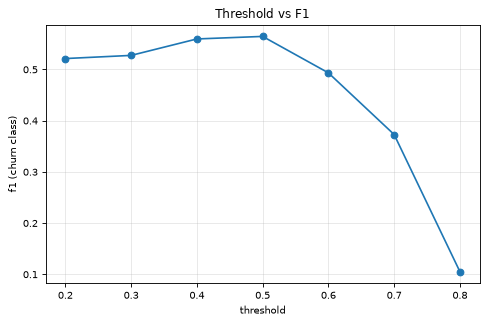

In [ ]:

clf = Pipeline([("prep", preprocess),
                ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
ths = np.linspace(0.2, 0.8, 7)
f1s = []
for t in ths:
    p = (proba >= t).astype(int)
    f1 = 2 * (p & y_test.values).sum() / max((p.sum() + y_test.sum()), 1)
    f1s.append(f1)
    print(f"threshold {t:.2f}: f1 {f1:.4f}")
fig, ax = plt.subplots()
ax.plot(ths, f1s, marker="o")
ax.set_xlabel("threshold"); ax.set_ylabel("f1 (churn class)")
ax.set_title("Threshold vs F1")
print(f"best threshold: {ths[int(np.argmax(f1s))]:.2f}")


## Notes

- `class_weight='balanced'` trades a little accuracy for a lot of recall.
- Threshold tuning on top squeezes out a bit more F1.
- For a retention campaign, recall is the right objective.